# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
#

## Customer Demographics Analysis

In [ ]:
# Age distribution


In [ ]:
# Job distribution


## Balance & Deposit Trends

In [ ]:
# Average balance by deposit subscription


## Campaign Effectiveness

In [ ]:
# Contact method analysis


In [ ]:
# Number of contacts vs deposit subscription


## Correlation Heatmap

In [ ]:
# Correlation of numerical variables


## Predictive Modeling (Logistic Regression)

In [ ]:


# Encode categorical variables

# Predictions


In [ ]:
# Feature importance


## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.

**Project Start**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("data.csv")

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [ ]:
df.shape

(41188, 21)

In [ ]:
df["age"]

,age
0,56
1,57
2,37
3,40
4,56
...,...
41183,73
41184,46
41185,56
41186,44


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df["age"].mean()

np.float64(40.02406040594348)

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
df.duplicated().sum()

np.int64(12)

In [ ]:
df["y"].value_counts()

,count
y,
no,36548
yes,4640


In [ ]:
df["y"].value_counts(normalize=True) * 100

,proportion
y,
no,88.734583
yes,11.265417


**Data Cleaning**

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
df.duplicated().sum()

np.int64(12)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 job
job
admin.           10419
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

 marital
marital
married     24921
single      11564
divorced     4611
unknown        80
Name: count, dtype: int64

 education
education
university.degree      12164
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
unknown                 1730
illiterate                18
Name: count, dtype: int64

 default
default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64

 housing
housing
yes        21571
no         18615
unknown      990
Name: count, dtype: int64

 loan
loan
no         33938
yes         6248
unknown      990
Name: count, dtype: int64

 contact
con

In [ ]:
df["y"].value_counts()

,count
y,
no,36537
yes,4639


In [ ]:
df["y"].value_counts(normalize=True) * 100

,proportion
y,
no,88.733728
yes,11.266272


In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


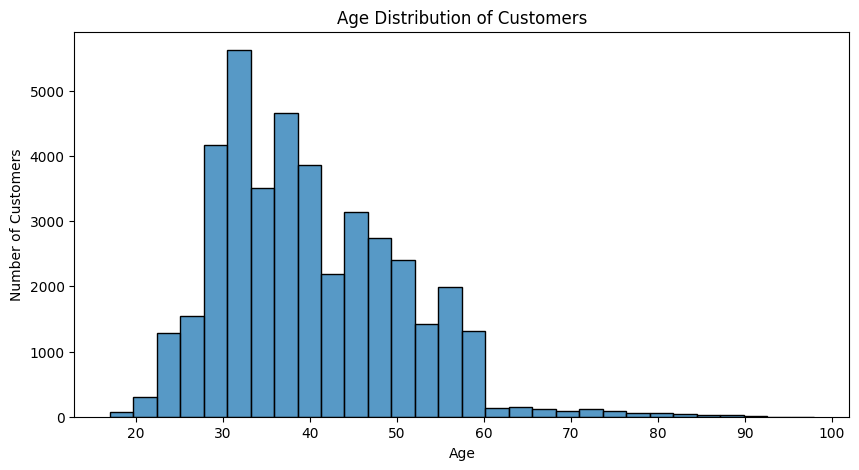

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="age", bins=30)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

In [ ]:
df[["age", "age_group"]].head()

,age,age_group
0,56,56-65
1,57,56-65
2,37,36-45
3,40,36-45
4,56,56-65


In [ ]:
age_subscription = df.groupby("age_group", observed=True)["y"].apply(
    lambda x: (x == "yes").mean() * 100
)

In [ ]:
age_subscription

,y
age_group,
18-25,20.960961
26-35,11.721908
36-45,8.505335
46-55,8.694071
56-65,15.221060
66+,46.925566


In [ ]:
age_subscription

,y
age_group,
18-25,20.960961
26-35,11.721908
36-45,8.505335
46-55,8.694071
56-65,15.221060
66+,46.925566


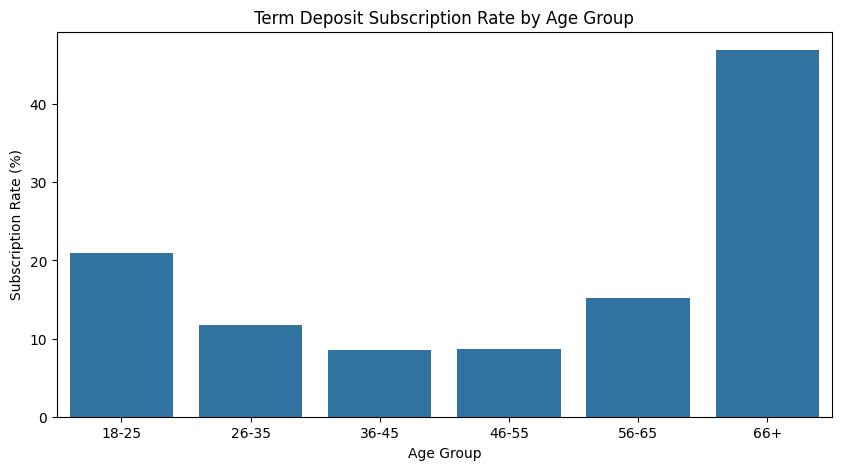

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=age_subscription.index,
    y=age_subscription.values
)

plt.title("Term Deposit Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")

plt.show()

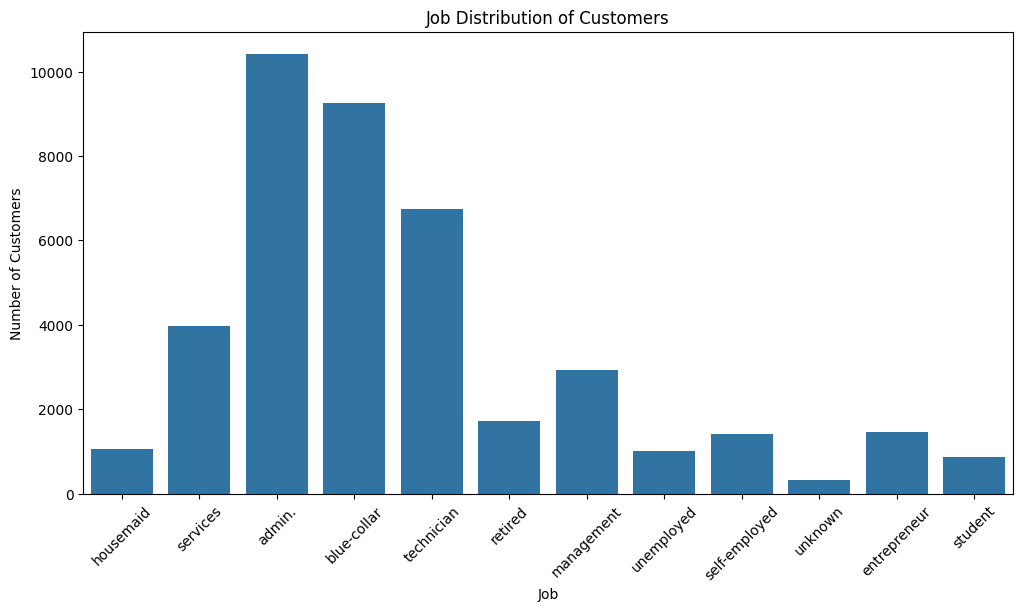

In [ ]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x="job")

plt.title("Job Distribution of Customers")
plt.xlabel("Job")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

In [ ]:
job_subscription = df.groupby("job")["y"].apply(
    lambda x: (x == "yes").mean() * 100
)

In [ ]:
job_subscription

,y
job,
admin.,12.966695
blue-collar,6.895061
entrepreneur,8.516484
housemaid,10.000000
management,11.217510
retired,25.261932
self-employed,10.485574
services,8.142173
student,31.428571


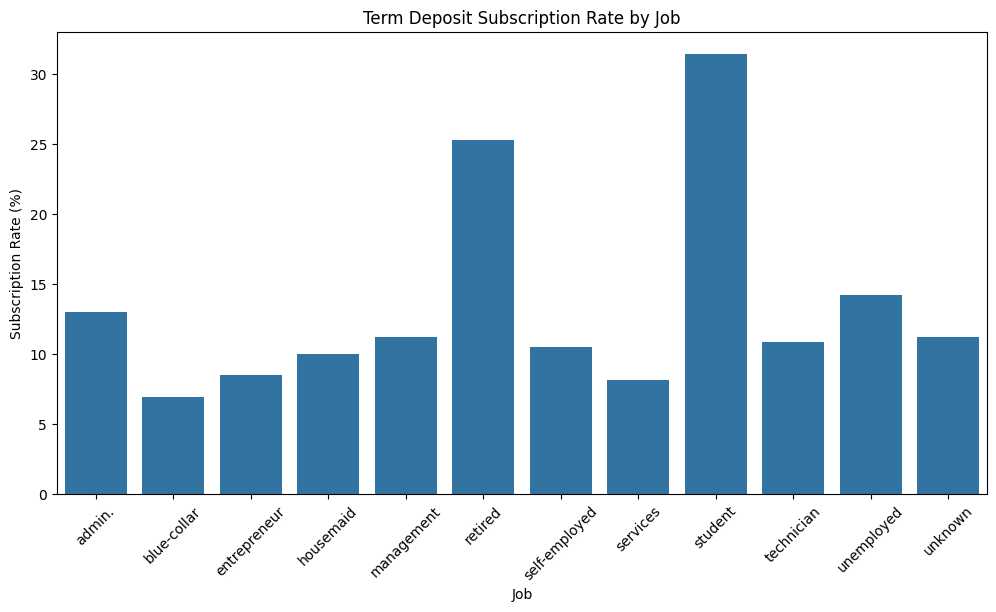

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=job_subscription.index,
    y=job_subscription.values
)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=45)

plt.show()

In [ ]:
df["education"].value_counts()

,count
education,
university.degree,12164
high.school,9512
basic.9y,6045
professional.course,5240
basic.4y,4176
basic.6y,2291
unknown,1730
illiterate,18


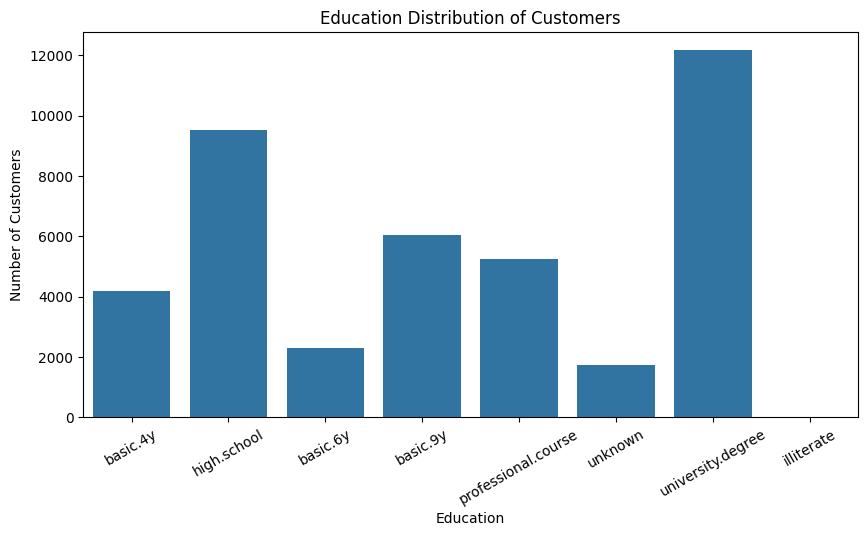

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="education")

plt.title("Education Distribution of Customers")
plt.xlabel("Education")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

In [ ]:
education_subscription = df.groupby("education")["y"].apply(
    lambda x: (x == "yes").mean() * 100
)

In [ ]:
education_subscription

,y
education,
basic.4y,10.249042
basic.6y,8.206024
basic.9y,7.824648
high.school,10.838940
illiterate,22.222222
professional.course,11.354962
university.degree,13.720816
unknown,14.508671


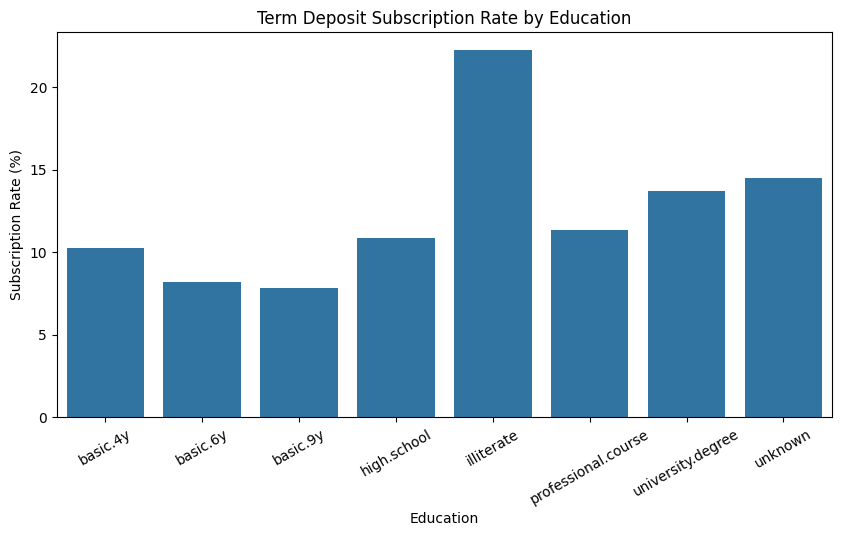

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=education_subscription.index,
    y=education_subscription.values
)

plt.title("Term Deposit Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [ ]:
df["marital"].value_counts()

,count
marital,
married,24921
single,11564
divorced,4611
unknown,80


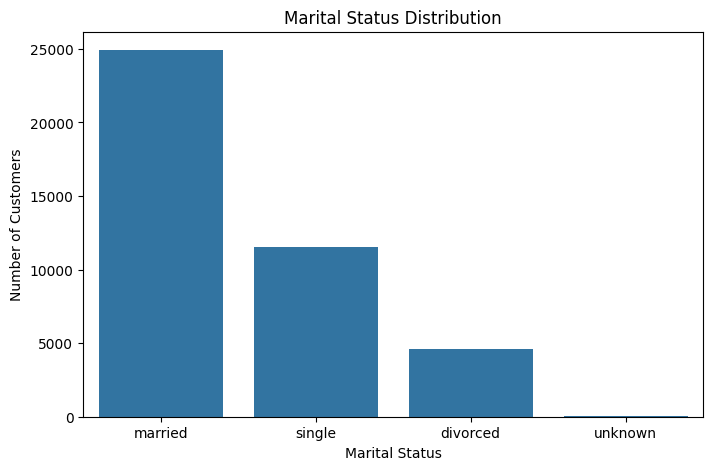

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="marital")

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
marital_subscription = df.groupby("marital")["y"].apply(
    lambda x: (x == "yes").mean() * 100
)

In [ ]:
marital_subscription

,y
marital,
divorced,10.323140
married,10.156093
single,14.008993
unknown,15.000000


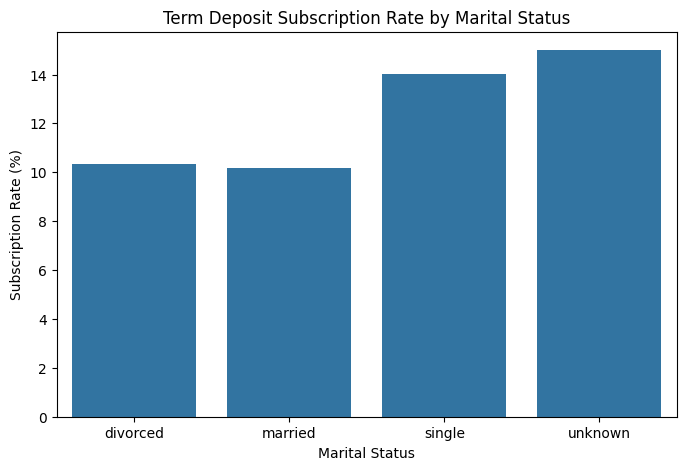

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=marital_subscription.index,
    y=marital_subscription.values
)

plt.title("Term Deposit Subscription Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Subscription Rate (%)")

plt.show()

In [ ]:
age_subscription_df = age_subscription.reset_index()
job_subscription_df = job_subscription.reset_index()
education_subscription_df = education_subscription.reset_index()
marital_subscription_df = marital_subscription.reset_index()

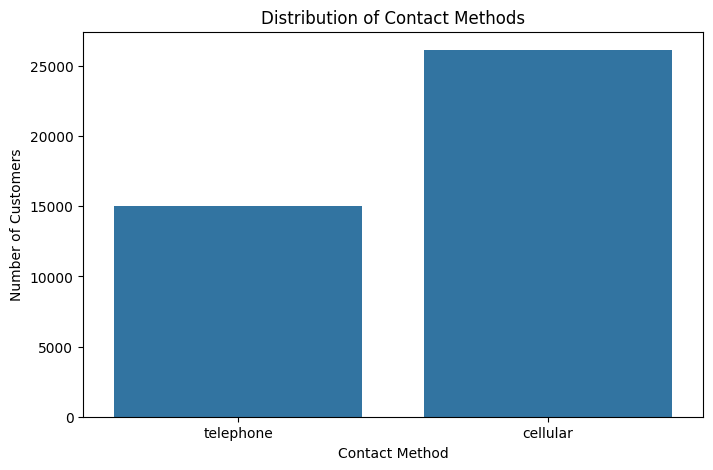

In [ ]:
# Contact method distribution

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="contact")

plt.title("Distribution of Contact Methods")
plt.xlabel("Contact Method")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
# Subscription rate by contact method

contact_subscription = df.groupby("contact")["y"].apply(
    lambda x: (x == "yes").mean() * 100
)

print(contact_subscription)

contact
cellular     14.738856
telephone     5.232365
Name: y, dtype: float64


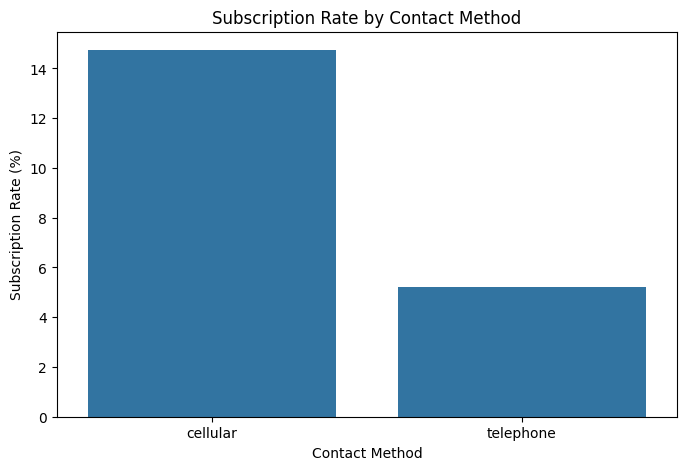

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=contact_subscription.index,
    y=contact_subscription.values
)

plt.title("Subscription Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")

plt.show()

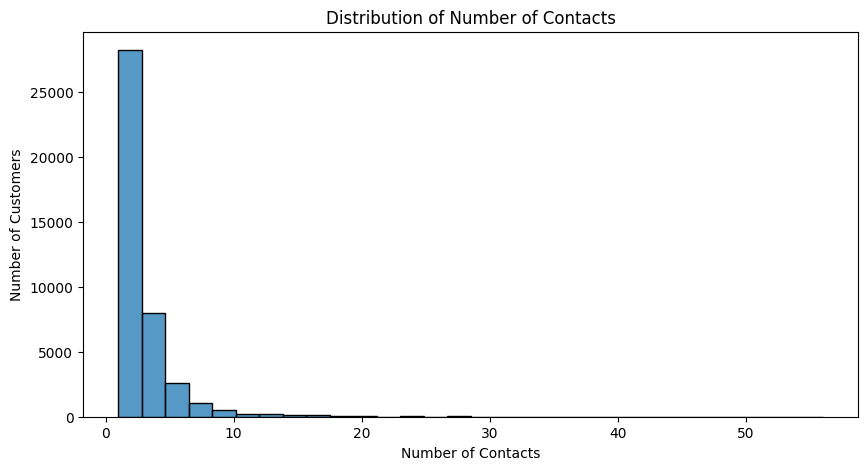

In [ ]:
# Distribution of number of contacts

plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="campaign", bins=30)

plt.title("Distribution of Number of Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
# Subscription rate by number of contacts

campaign_subscription = df.groupby("campaign")["y"].apply(
    lambda x: (x == "yes").mean() * 100
)

print(campaign_subscription)

campaign
1     13.037314
2     11.459122
3     10.749064
4      9.396226
5      7.504690
6      7.660878
7      6.041335
8      4.250000
9      6.007067
10     5.333333
11     6.779661
12     2.400000
13     4.347826
14     1.449275
15     3.921569
16     0.000000
17     6.896552
18     0.000000
19     0.000000
20     0.000000
21     0.000000
22     0.000000
23     6.250000
24     0.000000
25     0.000000
26     0.000000
27     0.000000
28     0.000000
29     0.000000
30     0.000000
31     0.000000
32     0.000000
33     0.000000
34     0.000000
35     0.000000
37     0.000000
39     0.000000
40     0.000000
41     0.000000
42     0.000000
43     0.000000
56     0.000000
Name: y, dtype: float64


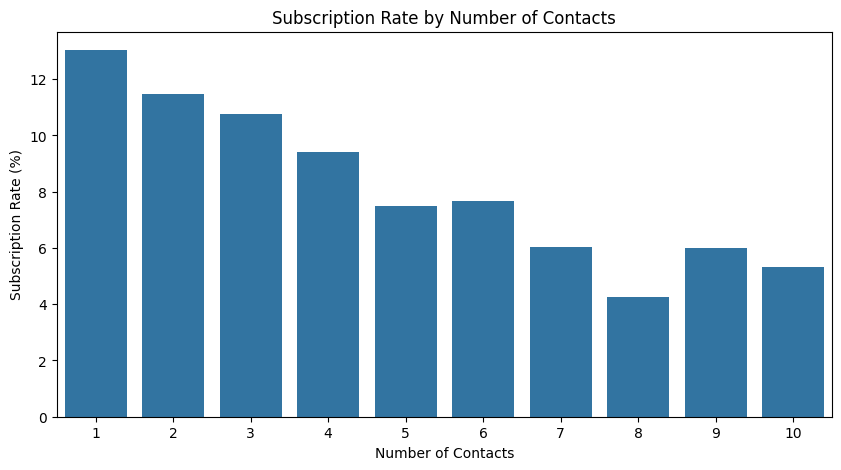

In [ ]:
# Select contact counts from 1 to 10

campaign_subscription_1_10 = campaign_subscription[
    campaign_subscription.index <= 10
]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=campaign_subscription_1_10.index,
    y=campaign_subscription_1_10.values
)

plt.title("Subscription Rate by Number of Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Subscription Rate (%)")

plt.show()

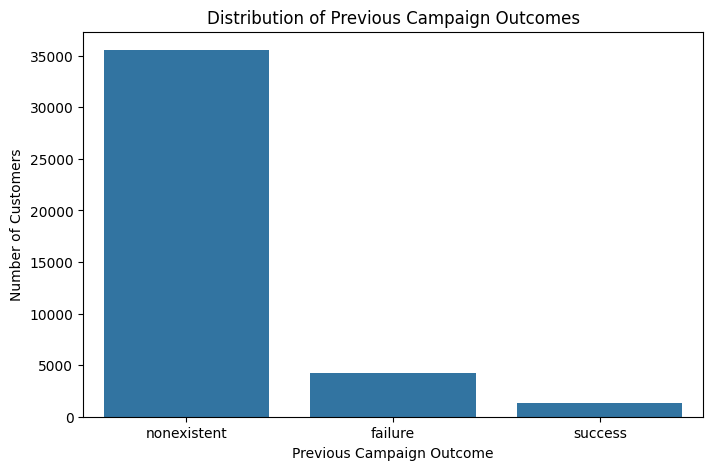

In [ ]:
# Previous campaign outcome distribution

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="poutcome")

plt.title("Distribution of Previous Campaign Outcomes")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
# Subscription rate by previous campaign outcome

previous_outcome_subscription = df.groupby("poutcome")["y"].apply(
    lambda x: (x == "yes").mean() * 100
)

print(previous_outcome_subscription)

poutcome
failure        14.228598
nonexistent     8.832382
success        65.112891
Name: y, dtype: float64


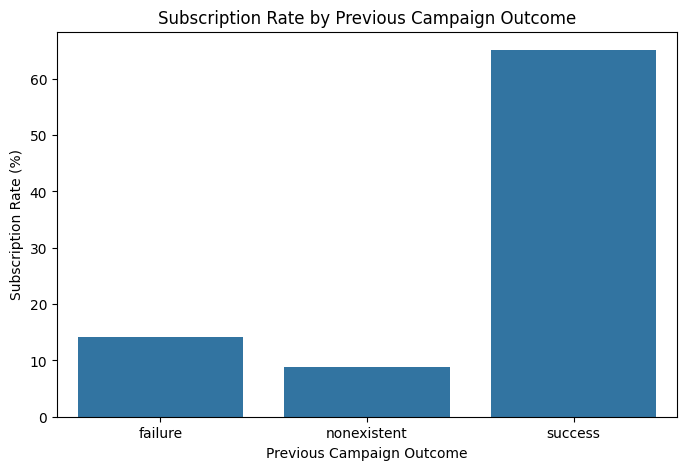

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=previous_outcome_subscription.index,
    y=previous_outcome_subscription.values
)

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")

plt.show()

In [ ]:
# Select numerical columns

numerical_columns = df.select_dtypes(include="number").columns

print(numerical_columns)

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


In [ ]:
# Calculate correlation matrix

correlation_matrix = df[numerical_columns].corr()

print(correlation_matrix)

                     age  duration  campaign     pdays  previous  \
age             1.000000 -0.000808  0.004622 -0.034381  0.024379   
duration       -0.000808  1.000000 -0.071765 -0.047556  0.020600   
campaign        0.004622 -0.071765  1.000000  0.052606 -0.079182   
pdays          -0.034381 -0.047556  0.052606  1.000000 -0.587508   
previous        0.024379  0.020600 -0.079182 -0.587508  1.000000   
emp.var.rate   -0.000242 -0.027941  0.150786  0.271063 -0.420587   
cons.price.idx  0.001009  0.005303  0.127826  0.078920 -0.203197   
cons.conf.idx   0.129075 -0.008126 -0.013657 -0.091374 -0.050929   
euribor3m       0.010852 -0.032861  0.135169  0.296946 -0.454571   
nr.employed    -0.017607 -0.044672  0.144129  0.372659 -0.501411   

                emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
age                -0.000242        0.001009       0.129075   0.010852   
duration           -0.027941        0.005303      -0.008126  -0.032861   
campaign            0.150786 

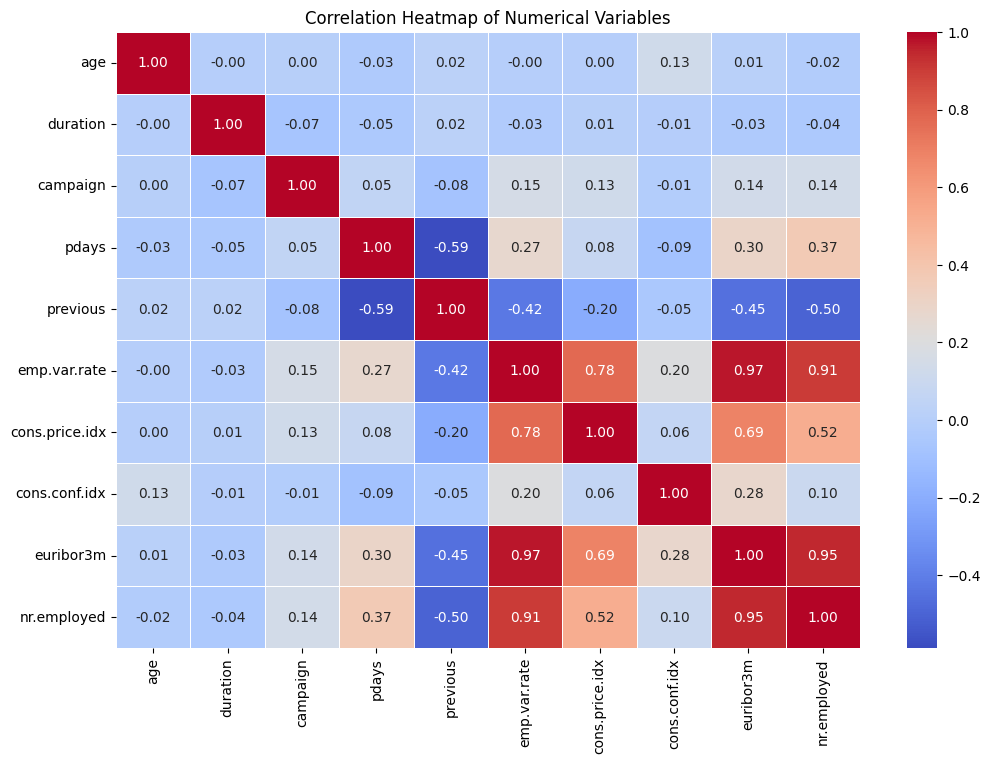

In [ ]:
# Correlation heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

In [ ]:
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [ ]:
sns.heatmap(...)

ValueError: Must pass 2-d input. shape=()

In [ ]:
annot=True

In [ ]:
cmap="coolwarm"

In [ ]:
fmt=".2f"

In [ ]:
linewidths=0.5

In [ ]:
# Find strongest correlations

correlation_pairs = correlation_matrix.unstack()

correlation_pairs = correlation_pairs[
    correlation_pairs.index.get_level_values(0) !=
    correlation_pairs.index.get_level_values(1)
]

correlation_pairs = correlation_pairs.sort_values(
    key=abs,
    ascending=False
)

print(correlation_pairs.head(20))

euribor3m       emp.var.rate      0.972244
emp.var.rate    euribor3m         0.972244
nr.employed     euribor3m         0.945146
euribor3m       nr.employed       0.945146
emp.var.rate    nr.employed       0.906949
nr.employed     emp.var.rate      0.906949
cons.price.idx  emp.var.rate      0.775293
emp.var.rate    cons.price.idx    0.775293
euribor3m       cons.price.idx    0.688180
cons.price.idx  euribor3m         0.688180
pdays           previous         -0.587508
previous        pdays            -0.587508
nr.employed     cons.price.idx    0.521945
cons.price.idx  nr.employed       0.521945
previous        nr.employed      -0.501411
nr.employed     previous         -0.501411
euribor3m       previous         -0.454571
previous        euribor3m        -0.454571
                emp.var.rate     -0.420587
emp.var.rate    previous         -0.420587
dtype: float64


In [ ]:
# Convert target column into numerical values

df["y"] = df["y"].map({
    "no": 0,
    "yes": 1
})

print(df["y"].value_counts())

y
0    36537
1     4639
Name: count, dtype: int64


In [ ]:
print(df[["y"]].head())

   y
0  0
1  0
2  0
3  0
4  0


In [ ]:
# Remove columns that should not be used for prediction

df_model = df.drop(
    columns=["y", "duration", "age_group"],
    errors="ignore"
)

print(df_model.head())
print(df_model.shape)

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  campaign  pdays  previous     poutcome  emp.var.rate  \
0   may         mon         1    999         0  nonexistent           1.1   
1   may         mon         1    999         0  nonexistent           1.1   
2   may         mon         1    999         0  nonexistent           1.1   
3   may         mon         1    999         0  nonexistent           1.1   
4   may         mon         1    999         0  nonexistent           1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
0          93.994    

In [ ]:
# Separate input features and target

X = df_model

y = df["y"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (41176, 19)
Target shape: (41176,)


In [ ]:
# Check categorical columns

categorical_columns = X.select_dtypes(
    include="object"
).columns

print(categorical_columns)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')


In [ ]:
# Convert categorical columns into numerical columns

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print(X_encoded.head())
print("Encoded features shape:", X_encoded.shape)

   age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
0   56         1    999         0           1.1          93.994   
1   57         1    999         0           1.1          93.994   
2   37         1    999         0           1.1          93.994   
3   40         1    999         0           1.1          93.994   
4   56         1    999         0           1.1          93.994   

   cons.conf.idx  euribor3m  nr.employed  job_blue-collar  ...  month_may  \
0          -36.4      4.857       5191.0            False  ...       True   
1          -36.4      4.857       5191.0            False  ...       True   
2          -36.4      4.857       5191.0            False  ...       True   
3          -36.4      4.857       5191.0            False  ...       True   
4          -36.4      4.857       5191.0            False  ...       True   

   month_nov  month_oct  month_sep  day_of_week_mon  day_of_week_thu  \
0      False      False      False             True           

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (32940, 52)
Testing data: (8236, 52)
Training target: (32940,)
Testing target: (8236,)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# Create Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create scaler
scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
print("Number of iterations used:", logistic_model.n_iter_)

Number of iterations used: [52]


In [ ]:
print("Training accuracy:", logistic_model.score(X_train_scaled, y_train))
print("Testing accuracy:", logistic_model.score(X_test_scaled, y_test))

Training accuracy: 0.9006071645415907
Testing accuracy: 0.898251578436134


In [ ]:
print("Number of iterations used:", logistic_model.n_iter_)
print("Training accuracy:", logistic_model.score(X_train_scaled, y_train))
print("Testing accuracy:", logistic_model.score(X_test_scaled, y_test))

Number of iterations used: [52]
Training accuracy: 0.9006071645415907
Testing accuracy: 0.898251578436134


In [ ]:
# Make predictions on testing data

y_pred = logistic_model.predict(X_test_scaled)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
# Predict subscription probabilities

y_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("First 20 subscription probabilities:")
print(y_probability[:20])

First 20 subscription probabilities:
[0.02793705 0.74798014 0.0535027  0.09972871 0.06259029 0.04253998
 0.09162537 0.06449257 0.08081854 0.03958755 0.0898162  0.04176623
 0.0464378  0.05071733 0.04793366 0.03835465 0.09295046 0.03763595
 0.03142591 0.04018105]


In [ ]:
print("First customer subscription probability:",
      y_probability[0] * 100, "%")

First customer subscription probability: 2.7937052773104183 %


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.898251578436134


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7308
           1       0.65      0.21      0.32       928

    accuracy                           0.90      8236
   macro avg       0.78      0.60      0.63      8236
weighted avg       0.88      0.90      0.87      8236



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7204  104]
 [ 734  194]]


In [ ]:
# Get feature importance from Logistic Regression

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": logistic_model.coef_[0]
})

# Calculate absolute coefficient values
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print(feature_importance.head(15))

                 Feature  Coefficient  Absolute_Coefficient
4           emp.var.rate    -2.243799              2.243799
5         cons.price.idx     1.172400              1.172400
8            nr.employed     0.484901              0.484901
36     contact_telephone    -0.360269              0.360269
7              euribor3m     0.310271              0.310271
40             month_jun    -0.207692              0.207692
2                  pdays    -0.204161              0.204161
42             month_may    -0.195624              0.195624
41             month_mar     0.167066              0.167066
37             month_aug     0.162295              0.162295
50  poutcome_nonexistent     0.151076              0.151076
51      poutcome_success     0.146078              0.146078
6          cons.conf.idx     0.133487              0.133487
43             month_nov    -0.123516              0.123516
1               campaign    -0.122972              0.122972


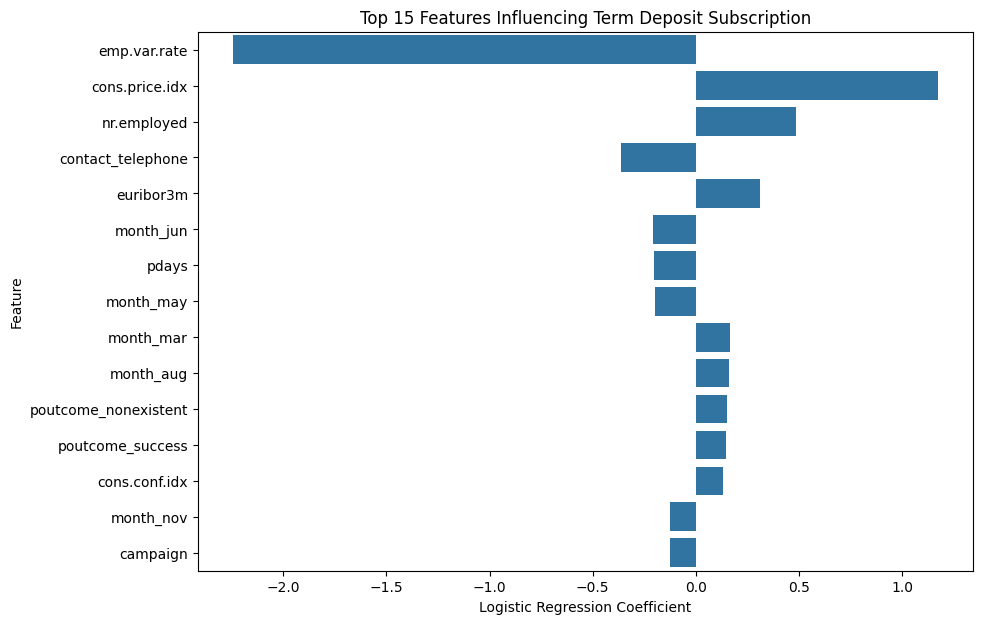

In [ ]:
# Plot top 15 important features

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 15 Features Influencing Term Deposit Subscription")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [ ]:
print(feature_importance.head(15).to_string(index=False))

             Feature  Coefficient  Absolute_Coefficient
        emp.var.rate    -2.243799              2.243799
      cons.price.idx     1.172400              1.172400
         nr.employed     0.484901              0.484901
   contact_telephone    -0.360269              0.360269
           euribor3m     0.310271              0.310271
           month_jun    -0.207692              0.207692
               pdays    -0.204161              0.204161
           month_may    -0.195624              0.195624
           month_mar     0.167066              0.167066
           month_aug     0.162295              0.162295
poutcome_nonexistent     0.151076              0.151076
    poutcome_success     0.146078              0.146078
       cons.conf.idx     0.133487              0.133487
           month_nov    -0.123516              0.123516
            campaign    -0.122972              0.122972


# **Final Business Insights and Project Summary**

# **Overall Business Insights**

1. The dataset contains more customers who did not subscribe than customers who subscribed. Therefore, the target variable is imbalanced.**bold text**

2.  Cellular communication had a higher subscription rate than telephone communication.

3.  Most customers were contacted between one and three times. The subscription rate generally decreased when customers were contacted repeatedly.

4.  Customers with a successful previous campaign outcome were more likely to subscribe again.

5.  Economic variables showed strong relationships with each other:

         emp.var.rate and euribor3m: 0.97         
         euribor3m and nr.employed: 0.95      
         emp.var.rate and nr.employed: 0.91

6.  The Logistic Regression model achieved approximately 89.83% accuracy.

7.  The model recall for subscribed customers was approximately 21%, meaning the model missed many actual subscribers.

8.  The most influential features were:

        emp.var.rate     
        cons.price.idx     
        nr.employed      
        contact_telephone      
        euribor3m       
        month_jun     
        pdays      
        month_may      
        month_mar       
        month_aug       

# **Business Recommendations**

     Prioritize customers with successful previous campaign outcomes.    
     Prefer cellular communication when possible.     
     Avoid contacting the same customer too many times.    
     Use predictive modeling to identify high-probability customers.     
     Focus marketing efforts on customers who are more likely to subscribe.     
     onitor economic conditions because economic variables strongly influenced the model.    
     Evaluate recall and F1-score along with accuracy because the dataset is imbalanced.     

# **Conclusion**

This project analyzed bank marketing campaign data to understand customer subscription behavior and identify factors associated with term deposit subscriptions.

The analysis covered customer demographics, campaign effectiveness, contact methods, previous campaign outcomes, economic indicators, correlation analysis, and predictive modeling.

The results showed that cellular contact had a higher subscription rate than telephone contact. Customers with successful previous campaign outcomes were more likely to subscribe. Repeated contact generally showed a negative relationship with subscription rate

The Logistic Regression model achieved approximately 89.83% accuracy, but its recall for subscribed customers was relatively low because the dataset was imbalanced.

Feature importance analysis identified emp.var.rate, cons.price.idx, nr.employed, and contact method as important predictive features.

Overall, this project demonstrates how data analytics and machine learning can help banks improve customer targeting, reduce unnecessary campaign effort, and make better marketing decisions.

In [ ]:
df.to_csv("bank_marketing_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
import os

print(os.path.exists("bank_marketing_cleaned.csv"))

True


In [ ]:
from google.colab import files

files.download("bank_marketing_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

df_powerbi = pd.read_csv("bank_marketing_cleaned.csv")

df_powerbi.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,age_group
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,56-65
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,56-65
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,36-45
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,36-45
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,56-65


In [ ]:
print("Rows:", df_powerbi.shape[0])
print("Columns:", df_powerbi.shape[1])
print(df_powerbi.columns.tolist())

Rows: 41176
Columns: 22
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'age_group']


In [ ]:
subscription_summary = (
    df_powerbi["y"]
    .value_counts()
    .reset_index()
)

subscription_summary.columns = ["Subscription_Status", "Customer_Count"]

subscription_summary

,Subscription_Status,Customer_Count
0,0,36537
1,1,4639


In [ ]:
subscription_rate = (
    df_powerbi.groupby("contact")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index()
)

subscription_rate.columns = ["Contact_Method", "Subscription_Rate"]

subscription_rate

,Contact_Method,Subscription_Rate
0,cellular,0.0
1,telephone,0.0


In [ ]:
subscription_summary.to_csv("subscription_summary.csv", index=False)
subscription_rate.to_csv("subscription_rate_by_contact.csv", index=False)

print("Power BI summary files created successfully.")

Power BI summary files created successfully.


In [ ]:
from google.colab import files

files.download("bank_marketing_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("subscription_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("subscription_rate_by_contact.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>